# CHARGEMENT DES PACKAGES

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
 
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# IMPORTATION DES DONNÉES

In [2]:
df = pd.read_csv('/kaggle/input/datasets/hassnainzaidi/resume-classification-dataset-for-nlp/Resume/Resume.csv')
 
print(" Dataset chargé avec succès !")
print(f" Dimensions : {df.shape}")
print(f"\n Colonnes disponibles :\n{df.columns.tolist()}")
print(f"\n Aperçu des données :")
print(df.head())
print(f"\n Informations :")
print(df.info())
print(f"\n Valeurs manquantes :\n{df.isnull().sum()}")

 Dataset chargé avec succès !
 Dimensions : (2484, 4)

 Colonnes disponibles :
['ID', 'Resume_str', 'Resume_html', 'Category']

 Aperçu des données :
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

 Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24

# EXPLORATION DES DONNÉES


 Nombre de catégories : 24

 Répartition par catégorie :
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


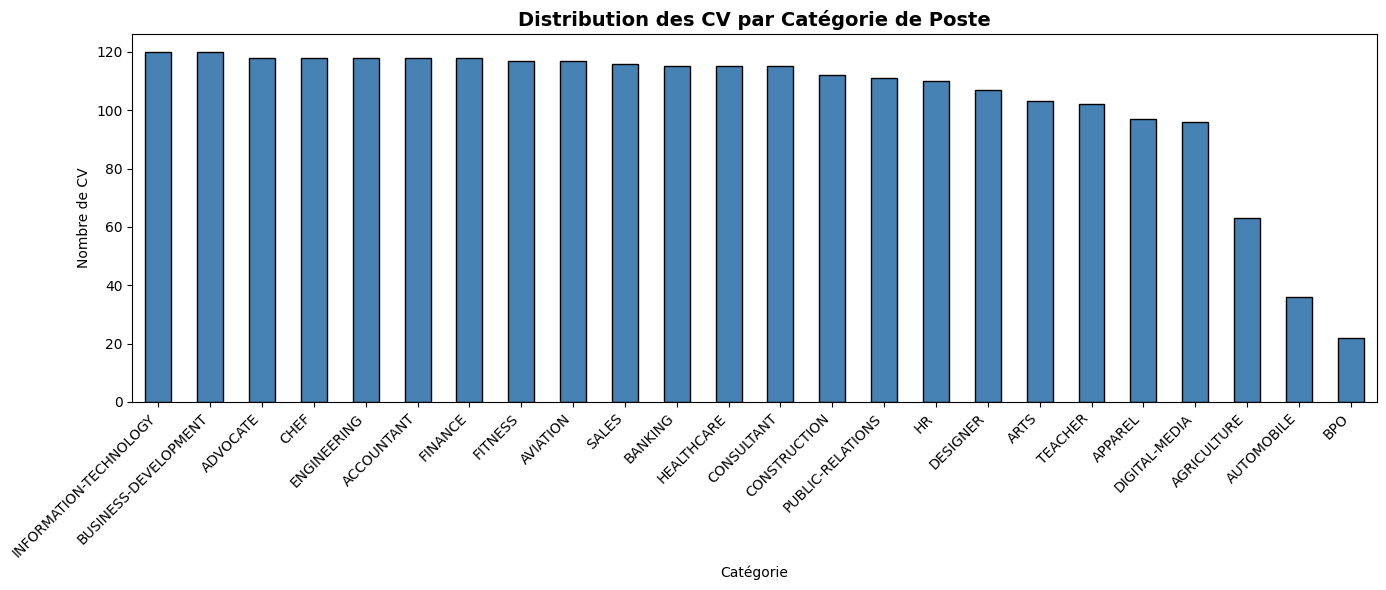

 Graphique sauvegardé : distribution_categories.png


In [3]:
if 'Category' in df.columns:
    print(f"\n Nombre de catégories : {df['Category'].nunique()}")
    print(f"\n Répartition par catégorie :")
    print(df['Category'].value_counts())
    # Visualisation
    plt.figure(figsize=(14, 6))
    df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Distribution des CV par Catégorie de Poste', fontsize=14, fontweight='bold')
    plt.xlabel('Catégorie')
    plt.ylabel('Nombre de CV')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('distribution_categories.png', dpi=150)
    plt.show()
    print(" Graphique sauvegardé : distribution_categories.png")

In [5]:
# Vérifier les types de chaque colonne
print("Types des colonnes :")
print(df.dtypes)

# Vérifier la colonne texte choisie
text_col = 'Resume_str'
print(f"\nType des valeurs dans '{text_col}' :")
print(df[text_col].apply(type).value_counts())

# Afficher les lignes problématiques
problemes = df[df[text_col].apply(lambda x: not isinstance(x, str))]
print(f"\n Lignes non-texte : {len(problemes)}")
print(problemes[[text_col]].head())




Types des colonnes :
ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

Type des valeurs dans 'Resume_str' :
Resume_str
<class 'str'>    2484
Name: count, dtype: int64

 Lignes non-texte : 0
Empty DataFrame
Columns: [Resume_str]
Index: []


# NETTOYAGE DU CV

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Nettoie le texte d'un CV :
    - Supprime URLs, emails, caractères spéciaux
    - Met en minuscules
    - Supprime les stopwords
    """
    #  CORRECTION : gérer tous les types
    if text is None:
        return ""
    if not isinstance(text, str):
        text = str(text)
    if pd.isna(text) or text.strip() == "" or text == "nan":
        return ""

    # Minuscules
    text = text.lower()

    # Supprimer URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Supprimer emails
    text = re.sub(r'\S+@\S+', '', text)

    # Supprimer numéros de téléphone
    text = re.sub(r'\b\d{10,}\b', '', text)

    # Garder uniquement lettres et espaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    # Supprimer stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return ' '.join(words)

# CORRECTION PRINCIPALE : forcer Resume_str directement
text_col = 'Resume_str'
print(f" Colonne texte utilisée : {text_col}")

# Appliquer le nettoyage
df['cleaned_text'] = df[text_col].apply(clean_text)

print(f"\n Exemple AVANT nettoyage :")
print(df[text_col].iloc[0][:300])
print(f"\n Exemple APRÈS nettoyage :")
print(df['cleaned_text'].iloc[0][:300])

 Colonne texte utilisée : Resume_str

 Exemple AVANT nettoyage :
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

 Exemple APRÈS nettoyage :
administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction


# VECTORISATION

In [7]:
vectorizer = TfidfVectorizer(
    max_features=5000,      # Garder les 5000 mots les plus importants
    ngram_range=(1, 2),     # Unigrammes et bigrammes
    min_df=2,               # Ignorer les mots très rares
    sublinear_tf=True       # Normalisation logarithmique
)
 
# Vectoriser tous les CV
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])
 
print(f" Matrice TF-IDF créée : {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} CV x {tfidf_matrix.shape[1]} termes")
 

print(" SYSTÈME DE SCORING ET FILTRAGE")

 
def filter_and_score_cvs(job_description, df, tfidf_matrix, vectorizer, top_n=10):
    """
    Filtre et score les CV en fonction d'une description de poste.
 
    Paramètres :
    - job_description : texte de l'offre d'emploi
    - df : dataframe des CV
    - tfidf_matrix : matrice TF-IDF des CV
    - vectorizer : vectoriseur TF-IDF entraîné
    - top_n : nombre de CV à retourner
 
    Retourne :
    - DataFrame des top_n CV classés par score
    """
 
    # Nettoyer la description du poste
    cleaned_job = clean_text(job_description)
 
    # Vectoriser la description du poste
    job_vector = vectorizer.transform([cleaned_job])
 
    # Calculer la similarité cosinus entre le poste et chaque CV
    similarities = cosine_similarity(job_vector, tfidf_matrix).flatten()
 
    # Ajouter les scores au dataframe
    results = df.copy()
    results['score'] = similarities
    results['score_pct'] = (similarities * 100).round(2)
 
    # Classer par score décroissant
    results = results.sort_values('score', ascending=False)
 
    # Sélectionner les top_n meilleurs CV
    top_results = results.head(top_n).reset_index(drop=True)
    top_results['rang'] = top_results.index + 1
 
    return top_results

 Matrice TF-IDF créée : (2484, 5000)
   → 2484 CV x 5000 termes
 SYSTÈME DE SCORING ET FILTRAGE


# TEST DU SYSTÈME(deux exemples...)

In [8]:
#  Offre 1 : Data Scientist 
job_data_scientist = """
We are looking for an experienced Data Scientist with strong skills in:
- Python programming (pandas, numpy, scikit-learn)

- Statistical analysis and data visualization
- SQL databases and big data tools 
- NLP and computer vision experience preferred
- Minimum 3 years of experience in data science
- Masters or PhD in Computer Science, Statistics or related field
- Data Science and data engineering
"""
 
print("\n Offre 1 : Data Scientist")
print("-" * 40)
results_ds = filter_and_score_cvs(
    job_description=job_data_scientist,
    df=df,
    tfidf_matrix=tfidf_matrix,
    vectorizer=vectorizer,
    top_n=5
)
 
# Affichage des résultats
cols_to_show = ['rang', 'score_pct']
if 'Category' in df.columns:
    cols_to_show.append('Category')
 
print(f"\n Top 5 CV pour le poste Data Scientist :\n")
print(results_ds[cols_to_show].to_string(index=False))
 
#  Offre 2 : Java Developer 
job_java_dev = """
We are hiring a Java Developer with expertise in:
- Core Java (Java 8+), Spring Boot, Hibernate
- RESTful API design and microservices architecture
- SQL and NoSQL databases (MySQL, MongoDB)
- Git version control and Agile/Scrum methodology
- Docker and Kubernetes knowledge is a plus
- 2+ years of professional Java development experience
"""
 
print("\n Offre 2 : Java Developer")
print("-" * 40)
results_java = filter_and_score_cvs(
    job_description=job_java_dev,
    df=df,
    tfidf_matrix=tfidf_matrix,
    vectorizer=vectorizer,
    top_n=5
)
print(f"\n Top 5 CV pour le poste Java Developer :\n")
print(results_java[cols_to_show].to_string(index=False))


 Offre 1 : Data Scientist
----------------------------------------

 Top 5 CV pour le poste Data Scientist :

 rang  score_pct               Category
    1      25.90             AUTOMOBILE
    2      21.67   BUSINESS-DEVELOPMENT
    3      20.34 INFORMATION-TECHNOLOGY
    4      17.77            ENGINEERING
    5      17.29             AUTOMOBILE

 Offre 2 : Java Developer
----------------------------------------

 Top 5 CV pour le poste Java Developer :

 rang  score_pct               Category
    1      31.73 INFORMATION-TECHNOLOGY
    2      29.11             CONSULTANT
    3      25.04               AVIATION
    4      22.83               DESIGNER
    5      21.79            ENGINEERING


# VISUALISATION DES SCORES

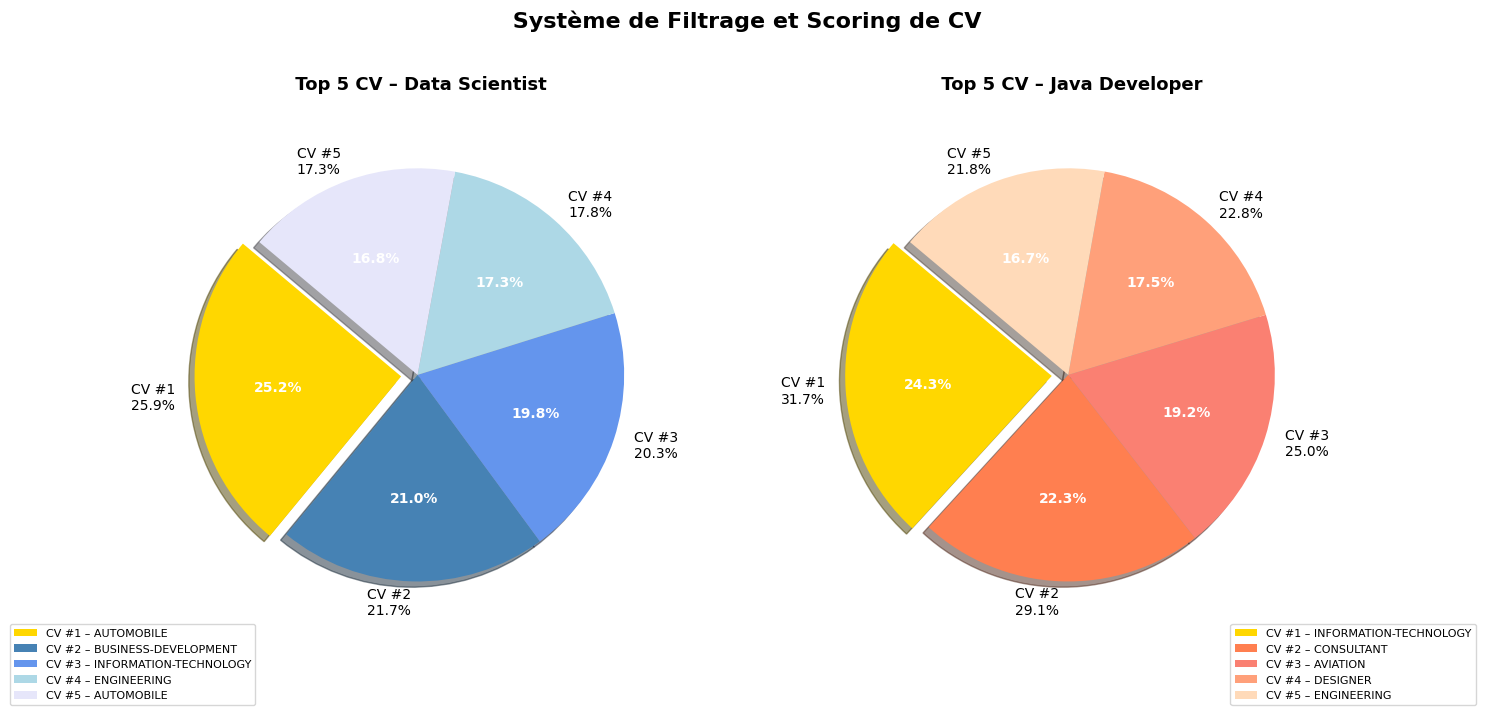

 Graphique pie sauvegardé : scores_matching_pie.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax1 = axes[0]
labels_ds = [f"CV #{i+1}\n{score:.1f}%" 
             for i, score in enumerate(results_ds['score_pct'])]

colors_ds = ['gold', 'steelblue', 'cornflowerblue', 'lightblue', 'lavender']

explode_ds = [0.08] + [0] * (len(results_ds) - 1)  

wedges, texts, autotexts = ax1.pie(
    results_ds['score_pct'],
    labels=labels_ds,
    colors=colors_ds[:len(results_ds)],
    explode=explode_ds,
    autopct='%1.1f%%',          
    startangle=140,
    shadow=True,
    textprops={'fontsize': 10}
)

# Style des pourcentages
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax1.set_title(' Top 5 CV – Data Scientist', 
              fontweight='bold', fontsize=13, pad=20)


ax2 = axes[1]

labels_java = [f"CV #{i+1}\n{score:.1f}%" 
               for i, score in enumerate(results_java['score_pct'])]

colors_java = ['gold', 'coral', 'salmon', 'lightsalmon', 'peachpuff']

explode_java = [0.08] + [0] * (len(results_java) - 1)

wedges2, texts2, autotexts2 = ax2.pie(
    results_java['score_pct'],
    labels=labels_java,
    colors=colors_java[:len(results_java)],
    explode=explode_java,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    textprops={'fontsize': 10}
)

for autotext in autotexts2:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax2.set_title(' Top 5 CV – Java Developer', 
              fontweight='bold', fontsize=13, pad=20)


plt.suptitle(' Système de Filtrage et Scoring de CV', 
             fontsize=16, fontweight='bold', y=1.02)

# Ajouter une légende avec les catégories si disponible
if 'Category' in results_ds.columns:
    legend_labels_ds = [f"CV #{i+1} – {cat}" 
                        for i, cat in enumerate(results_ds['Category'])]
    ax1.legend(wedges, legend_labels_ds,
               loc='lower left', fontsize=8,
               bbox_to_anchor=(-0.3, -0.15))

if 'Category' in results_java.columns:
    legend_labels_java = [f"CV #{i+1} – {cat}" 
                          for i, cat in enumerate(results_java['Category'])]
    ax2.legend(wedges2, legend_labels_java,
               loc='lower right', fontsize=8,
               bbox_to_anchor=(1.3, -0.15))

plt.tight_layout()
plt.savefig('scores_matching_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique pie sauvegardé : scores_matching_pie.png")

# EXEMPLE DE TESTE D'OFFRE D'EMPLOI

In [12]:
 def analyser_poste(titre_poste, description_poste, top_n=10):
    """
    Fonction principale pour analyser un poste et retourner les meilleurs CV.
    Appelez cette fonction avec votre propre offre !
    """
    print(f"\n Analyse pour le poste : {titre_poste}")
    
 
    results = filter_and_score_cvs(
        job_description=description_poste,
        df=df,
        tfidf_matrix=tfidf_matrix,
        vectorizer=vectorizer,
        top_n=top_n
    )
 
    print(f"\n TOP {top_n} CV classés par pertinence :\n")
    print(f"{'Rang':<6} {'Score':<12} {'Catégorie':<20}")
    print("-" * 40)
 
    for _, row in results.iterrows():
        cat = row.get('Category', 'N/A')
        print(f"  #{int(row['rang']):<5} {row['score_pct']:.2f}%{'':<6} {cat}")
 
    # Graphique
    plt.figure(figsize=(10, 6))
    colors = ['gold'] + ['steelblue'] * (len(results) - 1)
    plt.barh(
        [f"#{i+1}" for i in range(len(results))],
        results['score_pct'],
        color=colors,
        edgecolor='black'
    )
    plt.xlabel('Score de Matching (%)')
    plt.title(f' Top {top_n} CV – {titre_poste}', fontweight='bold', fontsize=13)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'top_cv_{titre_poste.replace(" ", "_")}.png', dpi=150)
    plt.show()
 
    return results


 Analyse pour le poste : HR Manager

 TOP 10 CV classés par pertinence :

Rang   Score        Catégorie           
----------------------------------------
  #1     24.82%       HR
  #2     23.82%       HR
  #3     22.78%       HR
  #4     21.24%       HR
  #5     21.03%       HR
  #6     20.80%       HR
  #7     20.42%       HR
  #8     19.98%       HR
  #9     19.98%       HR
  #10    19.97%       HR


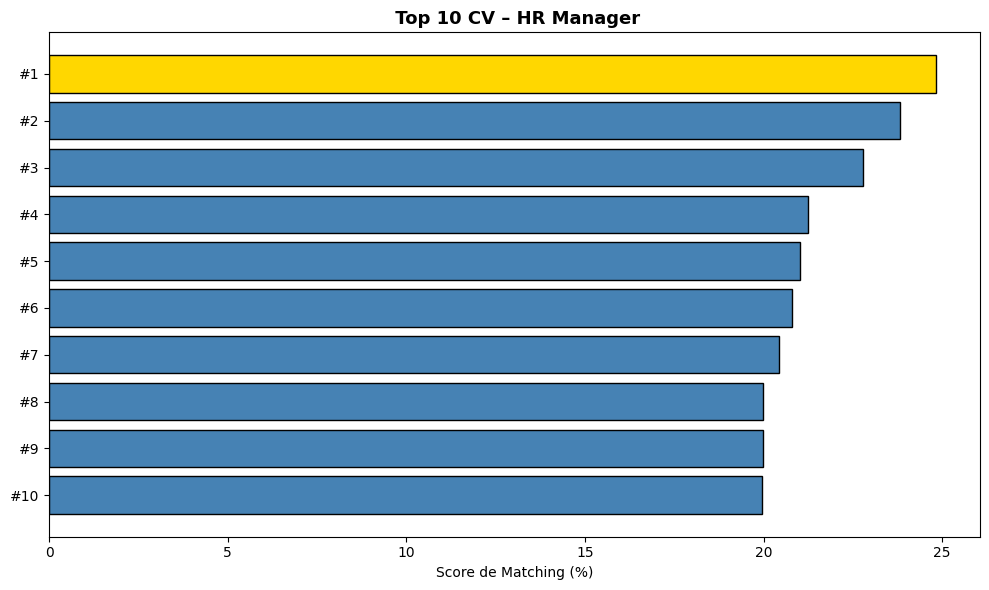

In [11]:
mon_poste = "HR Manager"
ma_description = """
Looking for an HR Manager with experience in:
- Recruitment and talent acquisition
- Employee relations and conflict resolution
- Payroll management and HRIS systems
- Training and development programs
- Labor law and compliance
- 5 years HR experience required
"""
 
resultats = analyser_poste(mon_poste, ma_description, top_n=10)